In [1]:
# imports 
import os
import numpy as np
import matplotlib.pyplot as plt

from pyrawph import L1_event
from pyrawph.sys_cfg import DATA_PATH, REPO_ROOT

In [2]:
# select product + load 
PRODUCT = str(DATA_PATH / "PHISAT-2_L1_000004663_20260216205626_20260216205629_97A6CEB3")
ev = L1_event.from_path(
    product_folder=PRODUCT,
    scene_id=0,
    product_kind="BC",
    multiband=True,
    as_float32=False,
    verbose=True,
)

[PyRawPh] Loading ΦSat-2 L1 from: C:\Users\Malo.DePastor\PyRawPh\data\PHISAT-2_L1_000004663_20260216205626_20260216205629_97A6CEB3


In [3]:
# info (PyRawS-like) 
ev.show_event_info()
ev.show_tiles_info()  

Event: scene_id=0 kind=BC
  folder: C:\Users\Malo.DePastor\PyRawPh\data\PHISAT-2_L1_000004663_20260216205626_20260216205629_97A6CEB3
  path: C:\Users\Malo.DePastor\PyRawPh\data\PHISAT-2_L1_000004663_20260216205626_20260216205629_97A6CEB3\bands\scene_0_BC_multiband.tiff
  shape: (8, 4096, 4096)   dtype: uint16
  crs: EPSG:4326
  bounds: BoundingBox(left=-141.93059130050244, bottom=59.831214491276874, right=-141.4994428456426, top=60.03740976135217)
  wavelengths_nm: [625, 490, 560, 665, 705, 740, 783, 842]
  gl_path: C:\Users\Malo.DePastor\PyRawPh\data\PHISAT-2_L1_000004663_20260216205626_20260216205629_97A6CEB3\geolocation\GL_scene_0.json
  processing_config: C:\Users\Malo.DePastor\PyRawPh\data\PHISAT-2_L1_000004663_20260216205626_20260216205629_97A6CEB3\processing_config.json
  n_tiles: 1
------------------Tile 0 ----------------------------
Name:  scene_0_BC
Sensing time:  2026-02-16 20:56:26
Creation time:  2026-02-16 20:56:29
Corners coordinates: 

	P_0 : [60.03740976135217, -141.9

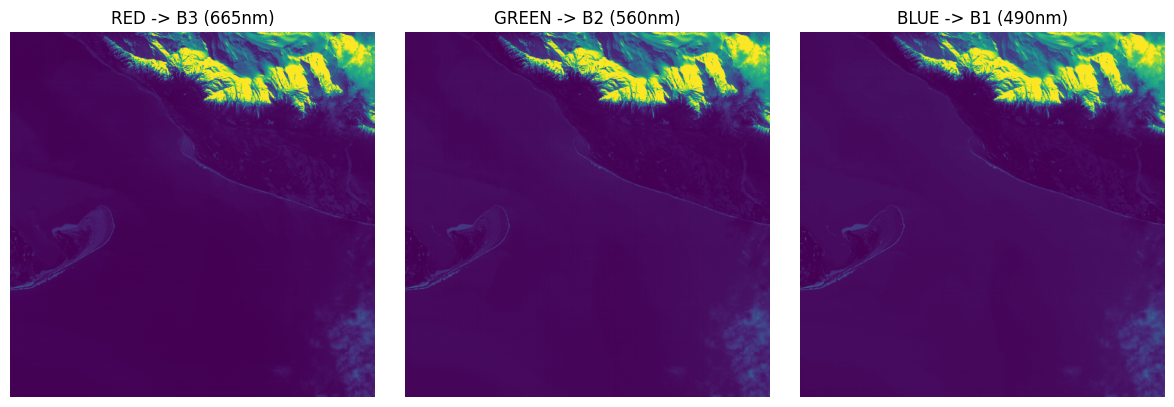

In [4]:
# show RGB bands (PyRawS-like) 
# shows individual bands (not RGB composite)
ev.show_bands(bands=["RED", "GREEN", "BLUE"], max_size=600, downsampling=True)

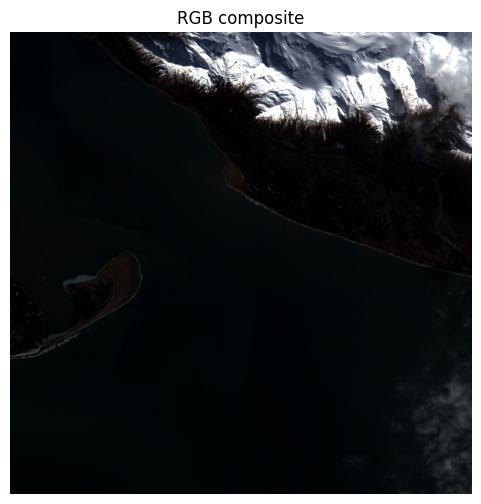

In [5]:
# quick RGB composite 
rgb = ev.rgb(("RED", "GREEN", "BLUE"))
plt.figure(figsize=(6, 6))
plt.imshow(rgb)
plt.axis("off")
plt.title("RGB composite")
plt.show()

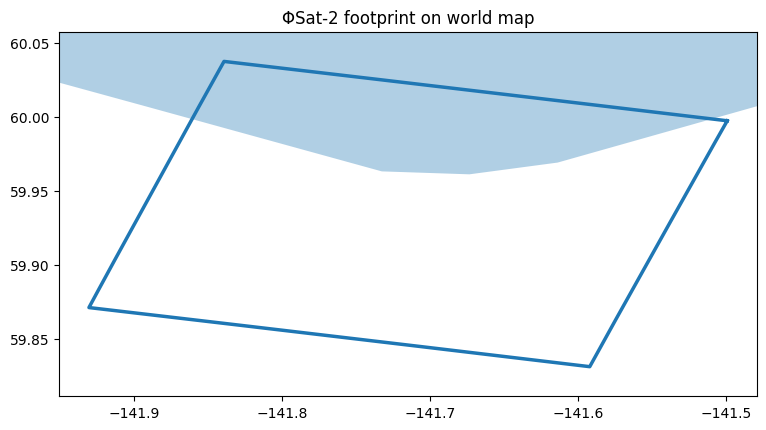

In [6]:
# plot location on world map (footprint)
ev.plot_location(mode="footprint", world=True)
plt.title("ΦSat-2 footprint on world map")
plt.show()

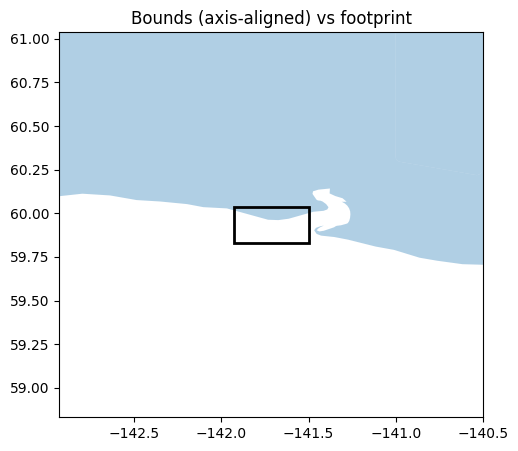

In [7]:
ev.plot_location(mode="bounds", world=True)
plt.title("Bounds (axis-aligned) vs footprint")
plt.show()

In [8]:
# tiles 
ev.make_tiles(tile_size=512, overlap=0, drop_last=False)
print("n_tiles:", ev.n_tiles)
print("first 5 tile names:", ev.get_tiles_names()[:5])

n_tiles: 64
first 5 tile names: ['tile_y0_x0_s512_o0', 'tile_y0_x512_s512_o0', 'tile_y0_x1024_s512_o0', 'tile_y0_x1536_s512_o0', 'tile_y0_x2048_s512_o0']


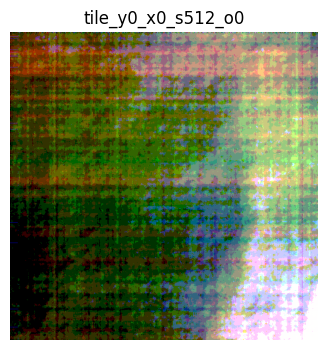

In [9]:
t0 = ev.get_tile(0)
plt.figure(figsize=(4,4))
plt.imshow(ev.rgb(("RED","GREEN","BLUE"), arr=t0.arr))  
plt.axis("off"); plt.title(t0.tile_name); plt.show()

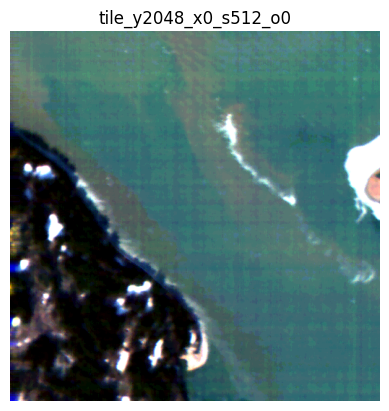

In [ ]:
# another one
tiles = ev.get_tiles_names()
mid = len(tiles)//2
t = ev.get_tile(mid)
plt.imshow(ev.rgb(("RED","GREEN","BLUE"), arr=t.arr))
plt.axis("off"); plt.title(t.tile_name); plt.show()

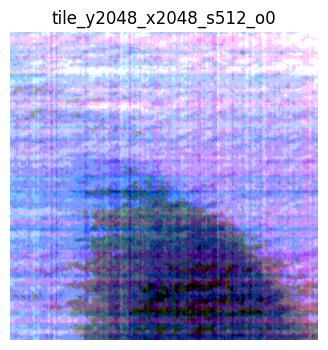

In [15]:
name = "tile_y2048_x2048_s512_o0"
i = ev.get_tiles_names().index(name)
t = ev.get_tile(i)

plt.figure(figsize=(4,4))
plt.imshow(ev.rgb(("RED","GREEN","BLUE"), arr=t.arr))
plt.axis("off")
plt.title(name)
plt.show()

In [10]:
# export a tile + a crop + NDVI
from pathlib import Path
OUT = str(Path(REPO_ROOT)/"outputs"/"demo")
os.makedirs(OUT, exist_ok=True)

# export tile 0 (GeoTIFF)
t0 = ev.get_tile(0)
TILE0_TIF = os.path.join(OUT, "tile0_BC.tif")
ev.export_to_tif(TILE0_TIF, arr=t0.arr, meta=t0.meta)
print("exported:", TILE0_TIF)

# export a center crop (GeoTIFF)
arr = ev.as_numpy()
H, W = arr.shape[1:]
crop_arr, crop_meta = ev.crop_px(H//4, 3*H//4, W//4, 3*W//4)
CROP_TIF = os.path.join(OUT, "center_crop_BC.tif")
ev.export_to_tif(CROP_TIF, arr=crop_arr, meta=crop_meta)
print("exported:", CROP_TIF)

# NDVI + export (1-band float32)
ndvi = ev.index("NDVI").astype(np.float32)
NDVI_TIF = os.path.join(OUT, "NDVI.tif")
ev.export_to_tif(NDVI_TIF, arr=ndvi, meta=ev.get_meta(), dtype="float32", nodata=-9999.0)
print("exported:", NDVI_TIF)

print("NDVI stats:", float(np.nanmin(ndvi)), float(np.nanmax(ndvi)))

exported: C:\Users\Malo.DePastor\PyRawPh\outputs\demo\tile0_BC.tif
exported: C:\Users\Malo.DePastor\PyRawPh\outputs\demo\center_crop_BC.tif
exported: C:\Users\Malo.DePastor\PyRawPh\outputs\demo\NDVI.tif
NDVI stats: -0.9295393228530884 0.31147539615631104


In [11]:
# quick visual checks of exports 
import rasterio

with rasterio.open(TILE0_TIF) as ds:
    print("tile0 tif:", ds.count, ds.height, ds.width, ds.dtypes, ds.crs)

with rasterio.open(CROP_TIF) as ds:
    print("crop tif:", ds.count, ds.height, ds.width, ds.dtypes, ds.crs)

with rasterio.open(NDVI_TIF) as ds:
    x = ds.read(1)
    print("ndvi tif:", ds.count, ds.height, ds.width, ds.dtypes, ds.crs)
    print("ndvi min/max:", float(np.min(x)), float(np.max(x)))

tile0 tif: 8 512 512 ('uint16', 'uint16', 'uint16', 'uint16', 'uint16', 'uint16', 'uint16', 'uint16') EPSG:4326
crop tif: 8 2048 2048 ('uint16', 'uint16', 'uint16', 'uint16', 'uint16', 'uint16', 'uint16', 'uint16') EPSG:4326
ndvi tif: 1 4096 4096 ('float32',) EPSG:4326
ndvi min/max: -0.9295393228530884 0.31147539615631104
